##Bulid A Basic Chatbot Using LangGraph

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from dotenv import load_dotenv
from groq import Groq
from langchain.chat_models import init_chat_model
import os

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key or groq_api_key.lower() in {"your_groq_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid GROQ_API_KEY in the .env file before creating the chat model."
    )

groq_client = Groq(api_key=groq_api_key)
available_models = {model.id for model in groq_client.models.list().data}
preferred_models = (
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "openai/gpt-oss-20b",
)
model_name = next(
    (model for model in preferred_models if model in available_models),
    None,
)
if model_name is None:
    raise RuntimeError(
        f"This GROQ_API_KEY cannot access a supported chat model. Available models: "
        f"{sorted(available_models)}"
    )

llm = init_chat_model(
    model_name,
    model_provider="groq",
    api_key=groq_api_key,
)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017ECAB52BA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017ECAB51A90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

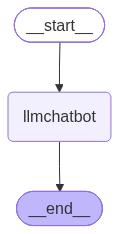

In [7]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response = graph.invoke({"messages": [{"role": "user", "content": "Hi"}]})

In [9]:
response["messages"][-1].content

'Hello! 👋 How can I help you today?'

In [10]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hi How are you?"}]}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great—thanks for asking. How can I help you today?


##Chatbot With Tools

In [11]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key or tavily_api_key.lower() in {"your_tavily_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid TAVILY_API_KEY in the .env file before using web search."
    )

tool = TavilySearch(max_results=2, tavily_api_key=tavily_api_key)
tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian C

In [12]:
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [13]:
tools=[tool,multiply]

In [14]:
llm_with_tool=llm.bind_tools(tools)

In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017ECAB52BA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017ECAB51A90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

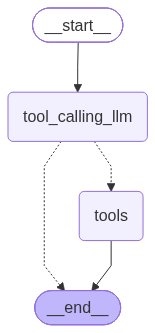

In [16]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [18]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Skipio acquired RapidTalk to expand its customer engagement messaging software. The combined platform applies conversational AI models to respond to inbound customer text messages, schedule sales appointments, and execute automated follow-up sequences. [...] Brightspot launched Esca Automations, a workflow automation engine for content management. The engine applies agentic artificial intelligence to translate text, tag digital assets, and route review cycles across software applications. [...] Helical Insight released an open-source business intelligence platform with integrated data analytics features. It uses AI to translate user text queries into SQL database commands, generate data visualizations, and construct interactive reporting d

In [19]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_9383f42c-b0d8-45e5-b0d0-42678198fb07)
 Call ID: fc_9383f42c-b0d8-45e5-b0d0-42678198fb07
  Args:
    query: recent AI news
    search_depth: basic
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Skipio acquired RapidTalk to expand its customer engagement messaging software. The combined platform applies conversational AI models to respond to inbound customer text messages, schedule sales appointments, and execute automated follow-up s

In [20]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

10


In [21]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_7c4691f1-95ce-4709-bd57-2a6ac5d60808)
 Call ID: fc_7c4691f1-95ce-4709-bd57-2a6ac5d60808
  Args:
    query: recent AI news 2026 September
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.transparencycoalition.ai/news/ai-legislative-update-september4-2026", "title": "AI Legislative Update: September 4, 2026", "content": "S 988, the Protect Workers in the Age of AI Act, would establish an AI Workforce Transition Program and AI Workforce Transition Fund within the North Carolina Department of Commerce. The Program would al

###ReAct Agent Architecture

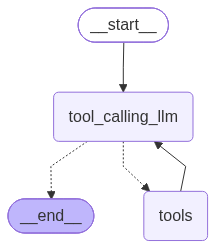

In [22]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_92b74102-aa5e-4dc2-9f73-3d98f2348adf)
 Call ID: fc_92b74102-aa5e-4dc2-9f73-3d98f2348adf
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.business-standard.com/amp/technology/artificial-intelligence/anthropic-researcher-quits-over-fears-of-out-of-control-ai-artificial-intelligence-systems-126090900370_1.html", "title": "Anthropic researcher quits over fears of 'out of control' AI systems | Artificial Intelligence News - Business Standard", "content": "The departure comes amid growi